ZERO-SHOT CLASSIFICATION ANALYSIS

1. BASIC STATISTICS
----------------------------------------
Total samples: 36253

Ground Truth Distribution:
exp_level_3
junior    19507
mid       15104
senior     1642
Name: count, dtype: int64

Predicted Distribution:
parsed_prediction
junior         14267
mid            13275
senior          8710
parse_error        1
Name: count, dtype: int64

Valid predictions (excluding unknown/parse errors): 36252 / 36253 (100.0%)

2. ACCURACY METRICS
----------------------------------------
Overall Accuracy: 0.5492 (54.92%)
Junior Accuracy: 0.6100 (61.00%) - 19507 samples
Mid Accuracy: 0.4371 (43.71%) - 15103 samples
Senior Accuracy: 0.8581 (85.81%) - 1642 samples

3. CLASSIFICATION REPORT
----------------------------------------
              precision    recall  f1-score   support

      junior     0.8340    0.6100    0.7046     19507
         mid     0.4973    0.4371    0.4652     15103
      senior     0.1618    0.8581    0.2722      1642

    accuracy    

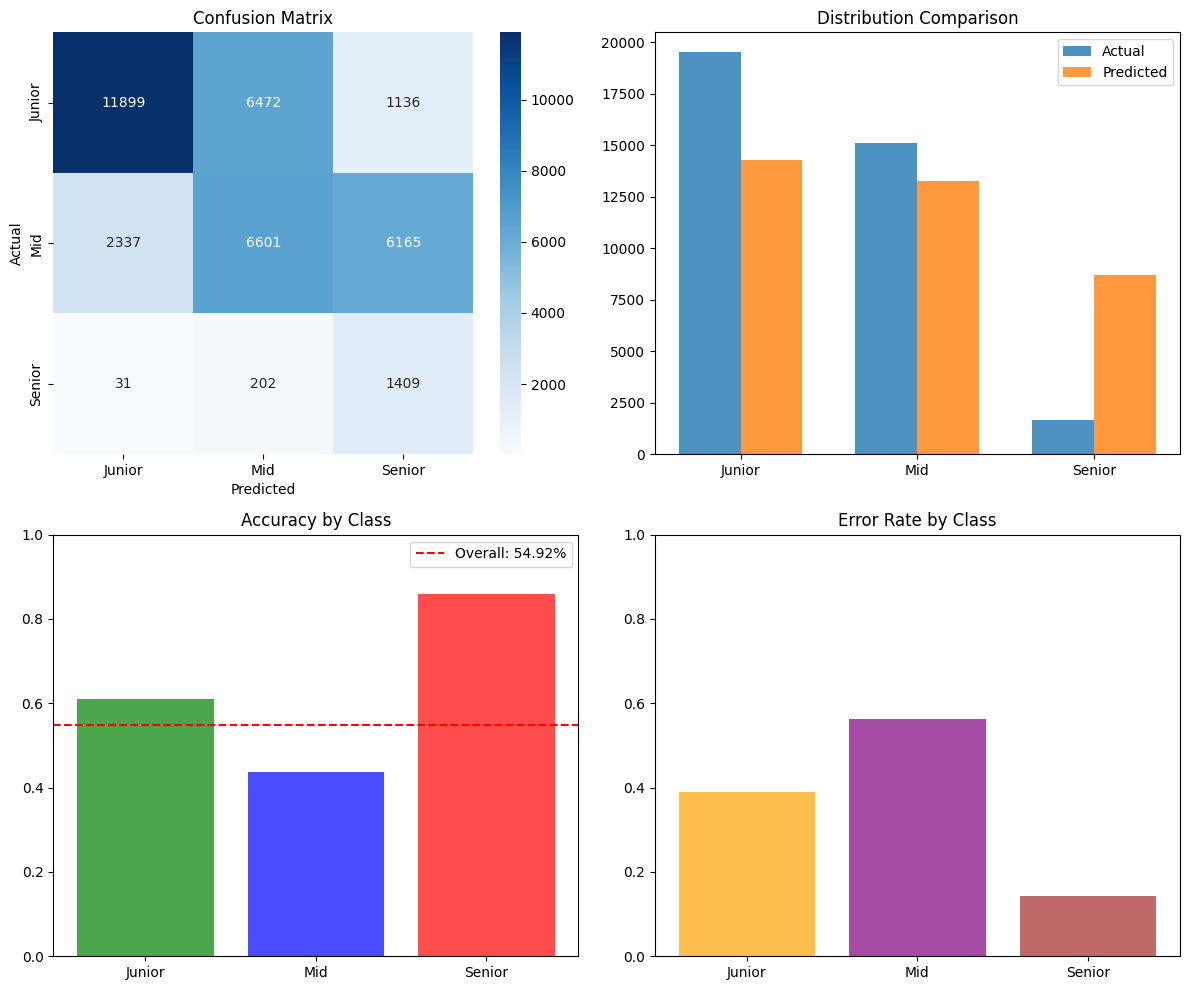

In [30]:
import pandas as pd
import numpy as np
import json
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.read_csv('merged_results_v2.csv')  # Replace with your file path

# Parse the raw_output JSON to extract predictions
def parse_prediction(raw_output):
    try:
        if isinstance(raw_output, str):
            # Clean the JSON string - remove markdown code blocks if present
            raw_output = raw_output.strip()
            if raw_output.startswith('```'):
                raw_output = raw_output.split('```')[1]
                if raw_output.startswith('json'):
                    raw_output = raw_output[4:]
            raw_output = raw_output.strip()
            
            data = json.loads(raw_output)
            return data.get('label', 'unknown')
        elif isinstance(raw_output, dict):
            return raw_output.get('label', 'unknown')
    except (json.JSONDecodeError, AttributeError) as e:
        return 'parse_error'

# Extract parsed predictions
df['parsed_prediction'] = df['raw_output'].apply(parse_prediction)

# Map to consistent labels
label_map = {
    'junior': 'junior',
    'mid': 'mid',
    'senior': 'senior',
    'unknown': 'unknown',
    'parse_error': 'parse_error'
}

df['parsed_prediction'] = df['parsed_prediction'].map(label_map).fillna('unknown')

print("="*60)
print("ZERO-SHOT CLASSIFICATION ANALYSIS")
print("="*60)

# 1. Basic Statistics
print("\n1. BASIC STATISTICS")
print("-" * 40)
print(f"Total samples: {len(df)}")
print(f"\nGround Truth Distribution:")
print(df['exp_level_3'].value_counts())
print(f"\nPredicted Distribution:")
print(df['parsed_prediction'].value_counts())

# 2. Filter out parse errors and unknowns for accuracy calculation
df_valid = df[(df['parsed_prediction'] != 'unknown') & 
              (df['parsed_prediction'] != 'parse_error')].copy()

print(f"\nValid predictions (excluding unknown/parse errors): {len(df_valid)} / {len(df)} ({len(df_valid)/len(df)*100:.1f}%)")

# 3. Accuracy Metrics
print("\n2. ACCURACY METRICS")
print("-" * 40)
accuracy = accuracy_score(df_valid['exp_level_3'], df_valid['parsed_prediction'])
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Per-class accuracy
for level in ['junior', 'mid', 'senior']:
    mask = df_valid['exp_level_3'] == level
    if mask.sum() > 0:
        class_acc = accuracy_score(df_valid[mask]['exp_level_3'], 
                                   df_valid[mask]['parsed_prediction'])
        print(f"{level.capitalize()} Accuracy: {class_acc:.4f} ({class_acc*100:.2f}%) - {mask.sum()} samples")

# 4. Classification Report
print("\n3. CLASSIFICATION REPORT")
print("-" * 40)
print(classification_report(df_valid['exp_level_3'], 
                           df_valid['parsed_prediction'],
                           digits=4))

# 5. Confusion Matrix
print("\n4. CONFUSION MATRIX")
print("-" * 40)
cm = confusion_matrix(df_valid['exp_level_3'], 
                      df_valid['parsed_prediction'], 
                      labels=['junior', 'mid', 'senior'])

print("                Predicted")
print("                Junior  Mid   Senior")
confusion_df = pd.DataFrame(cm, 
                            index=['Actual Junior', 'Actual Mid', 'Actual Senior'],
                            columns=['Junior', 'Mid', 'Senior'])
print(confusion_df)

# 6. Error Analysis
print("\n5. ERROR ANALYSIS")
print("-" * 40)
df_valid['is_correct'] = df_valid['exp_level_3'] == df_valid['parsed_prediction']
errors = df_valid[~df_valid['is_correct']]

print(f"Total errors: {len(errors)} / {len(df_valid)} ({len(errors)/len(df_valid)*100:.2f}%)")

# Error types
print("\nError breakdown by type:")
error_types = errors.groupby(['exp_level_3', 'parsed_prediction']).size().reset_index(name='count')
for _, row in error_types.iterrows():
    print(f"  {row['exp_level_3']} → {row['parsed_prediction']}: {row['count']} cases")

# 7. Analyze specific misclassifications
print("\n6. SAMPLE MISCLASSIFICATIONS")
print("-" * 40)
for idx, row in errors.head(5).iterrows():
    print(f"\nTitle: {row['title'][:80]}...")
    print(f"Actual: {row['exp_level_3']} | Predicted: {row['parsed_prediction']}")
    print(f"Years mentioned: {row.get('years_experience', 'N/A')}")
    print(f"Salary: {row.get('normalized_salary', 'N/A')}")

# 8. Visualization
print("\n7. CREATING VISUALIZATIONS...")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Junior', 'Mid', 'Senior'],
            yticklabels=['Junior', 'Mid', 'Senior'],
            ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# Distribution comparison
x = np.arange(3)
width = 0.35
actual_counts = df_valid['exp_level_3'].value_counts()[['junior', 'mid', 'senior']].values
pred_counts = df_valid['parsed_prediction'].value_counts()[['junior', 'mid', 'senior']].values

axes[0, 1].bar(x - width/2, actual_counts, width, label='Actual', alpha=0.8)
axes[0, 1].bar(x + width/2, pred_counts, width, label='Predicted', alpha=0.8)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(['Junior', 'Mid', 'Senior'])
axes[0, 1].set_title('Distribution Comparison')
axes[0, 1].legend()

# Accuracy by class
class_accuracies = []
for level in ['junior', 'mid', 'senior']:
    mask = df_valid['exp_level_3'] == level
    if mask.sum() > 0:
        acc = accuracy_score(df_valid[mask]['exp_level_3'], 
                            df_valid[mask]['parsed_prediction'])
        class_accuracies.append(acc)

axes[1, 0].bar(['Junior', 'Mid', 'Senior'], class_accuracies, color=['green', 'blue', 'red'], alpha=0.7)
axes[1, 0].set_title('Accuracy by Class')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].axhline(y=accuracy, color='r', linestyle='--', label=f'Overall: {accuracy:.2%}')
axes[1, 0].legend()

# Error rate by actual class
error_rates = []
for level in ['junior', 'mid', 'senior']:
    mask = df_valid['exp_level_3'] == level
    if mask.sum() > 0:
        error_rate = (~df_valid[mask]['is_correct']).sum() / mask.sum()
        error_rates.append(error_rate)

axes[1, 1].bar(['Junior', 'Mid', 'Senior'], error_rates, color=['orange', 'purple', 'brown'], alpha=0.7)
axes[1, 1].set_title('Error Rate by Class')
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('classification_analysis.png', dpi=300)
print("Saved visualization to 'classification_analysis.png'")

# 9. Save detailed results
print("\n8. SAVING RESULTS...")

# Save misclassifications
errors.to_csv('misclassifications.csv', index=False)
print(f"Saved {len(errors)} misclassifications to 'misclassifications.csv'")

# Save summary statistics
summary = {
    'total_samples': len(df),
    'valid_predictions': len(df_valid),
    'accuracy': float(accuracy),
    'per_class_accuracy': {
        'junior': float(class_accuracies[0]) if len(class_accuracies) > 0 else None,
        'mid': float(class_accuracies[1]) if len(class_accuracies) > 1 else None,
        'senior': float(class_accuracies[2]) if len(class_accuracies) > 2 else None
    },
    'confusion_matrix': cm.tolist(),
    'error_count': len(errors),
    'error_rate': float(len(errors) / len(df_valid))
}

import json
with open('classification_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("Saved summary to 'classification_summary.json'")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

COMPREHENSIVE OSINT ANALYSIS RESULTS

1. LOADING PREDICTION RESULTS

✓ Loaded predictions: 36253 rows
✓ Columns: ['company_name', 'title', 'description', 'location', 'formatted_work_type', 'formatted_experience_level', 'skills_desc', 'normalized_salary', 'exp_level_3', 'salary_signal', 'skills_desc_clean', 'skill_count', 'skill_count_band', 'advanced_skill_count', 'mid_skill_count', 'skill_signal', 'skill_signal_num', 'title_signal', 'title_signal_num', 'years_experience', 'years_signal', 'years_signal_num', 'predicted_level', 'raw_output', 'chunk_id']

Sample predictions:
                    company_name                                      title  \
0        Galerie Candy and Gifts                  Quality Assurance Manager   
1             Webologix Ltd/ INC                          Anaplan Developer   
2                          Crisp             Account Executive - Mid-Market   
3                Dexterity, Inc.                 Senior Mechanical Engineer   
4  Premier Brands Group H

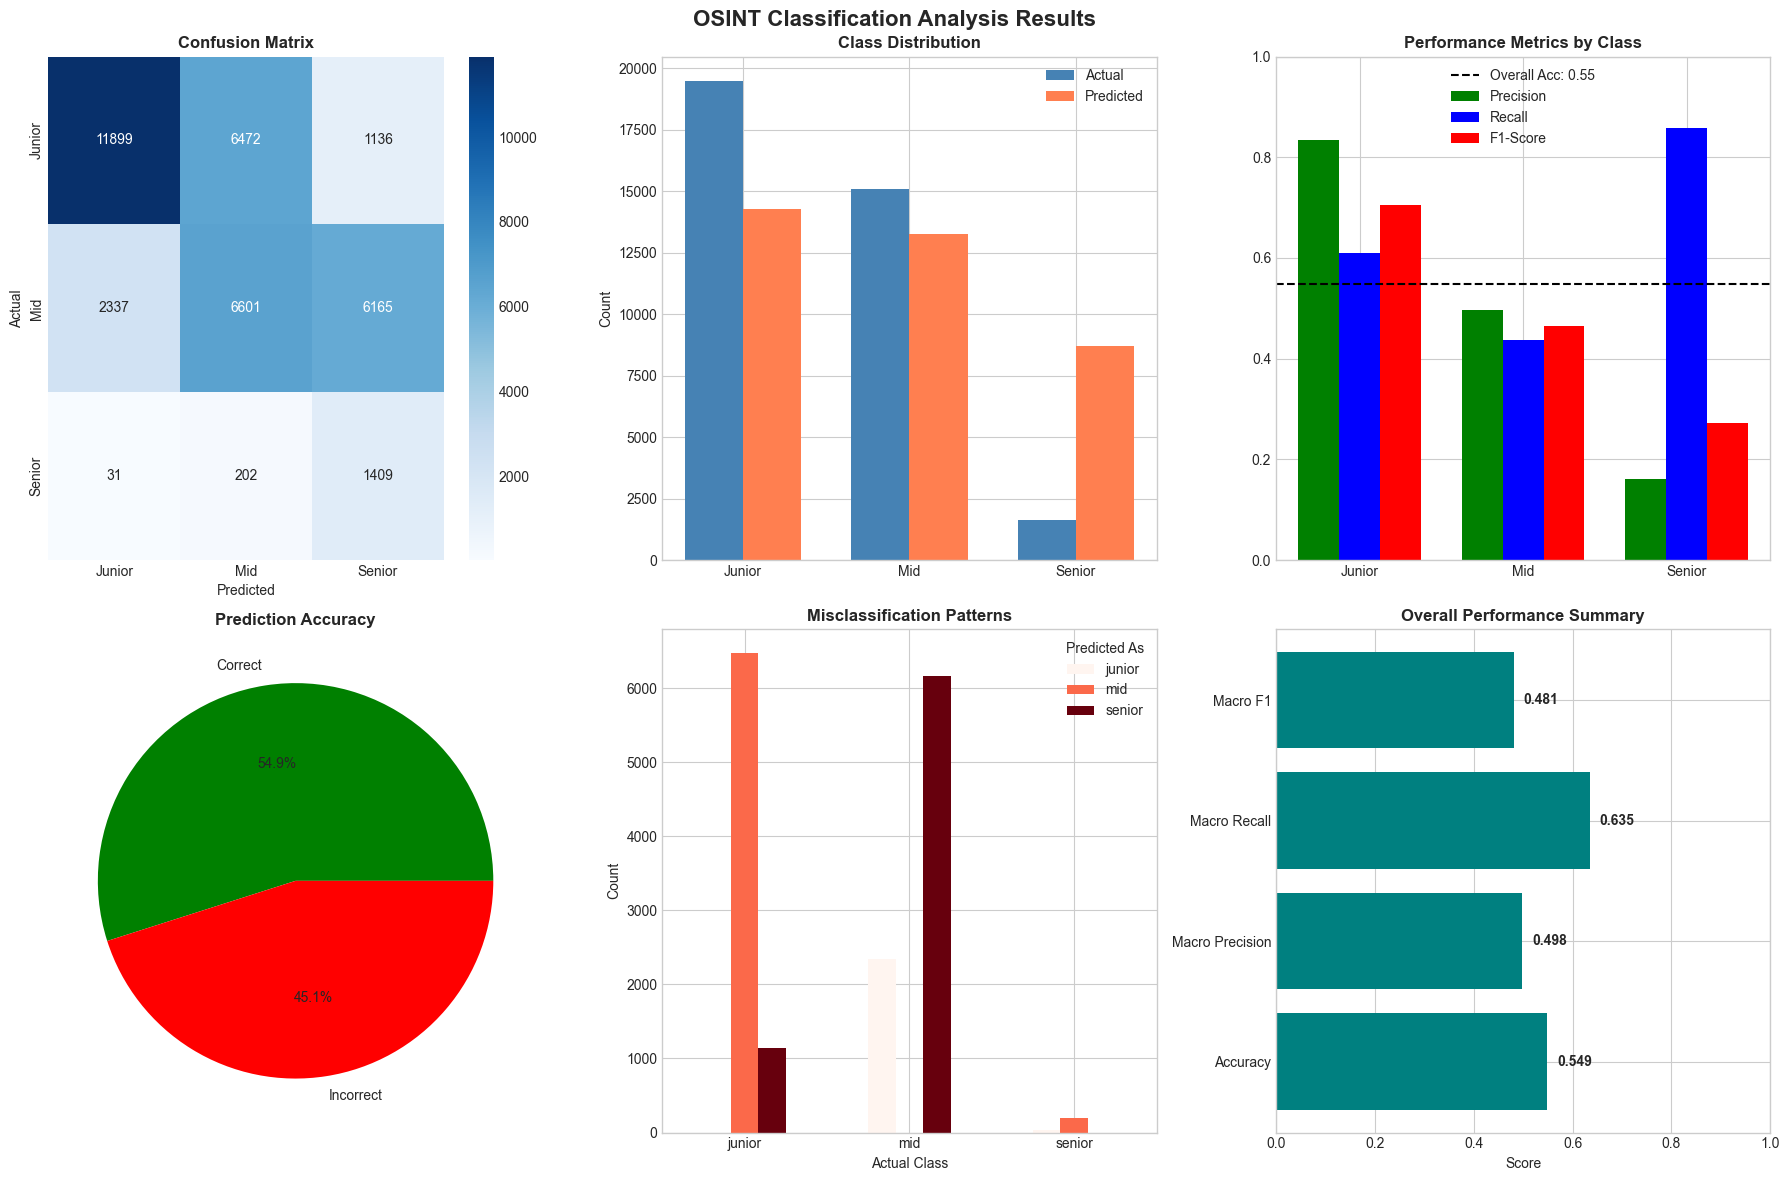


4. CONTRADICTION/CONTROVERSY ANALYSIS

⚠️  contradiction_summary.json not found. Skipping contradiction analysis.

📊 BASIC CONTRADICTION METRICS FROM PREDICTIONS:
------------------------------------------------------------
Total Predictions:             36,253
Valid Predictions:             36,252
Unknown/Invalid Predictions:   1
Unknown Rate:                  0.00%

📈 PER-CLASS DISAGREEMENT ANALYSIS:
------------------------------------------------------------

JUNIOR:
  Actual Count:        19507
  Predicted Count:     14267
  Correct Predictions: 11899
  Disagreement Rate:   39.00%

MID:
  Actual Count:        15103
  Predicted Count:     13275
  Correct Predictions:  6601
  Disagreement Rate:   56.29%

SENIOR:
  Actual Count:         1642
  Predicted Count:      8710
  Correct Predictions:  1409
  Disagreement Rate:   14.19%

5. STATISTICAL HYPOTHESIS TESTING RESULTS

⚠️  mistral_ztest_summary.json not found. Skipping statistical test analysis.

6. DETAILED ERROR ANALYSIS

🔍 ERRO

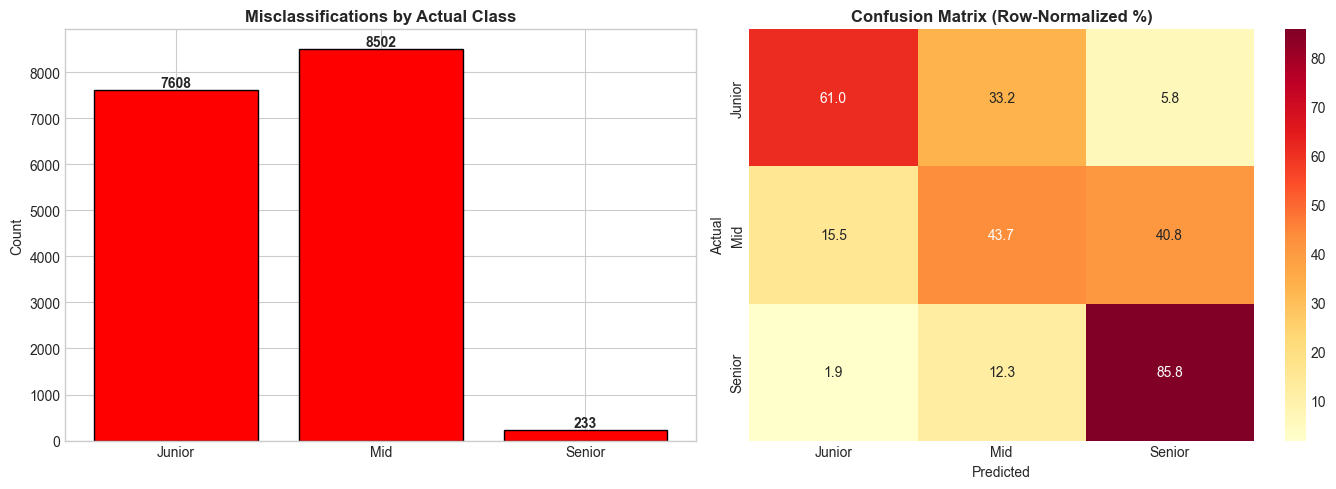


7. OVERALL PERFORMANCE SUMMARY

📊 KEY METRICS:
------------------------------------------------------------
✓ Total Samples Analyzed:        36,252
✓ Overall Accuracy:              54.92%
✓ Macro Precision:               49.77%
✓ Macro Recall:                  63.51%
✓ Macro F1-Score:                48.07%

🏆 Best Performing Class:        JUNIOR (F1: 70.46%)
⚠️  Worst Performing Class:       SENIOR (F1: 27.22%)

📈 PERFORMANCE ASSESSMENT:
------------------------------------------------------------
❌ POOR: Model requires significant improvement

💡 RECOMMENDATIONS:
------------------------------------------------------------
• Focus on improving senior classification
  - Current F1-score: 27.22%
  - Consider adding more training examples for this class
  - Review feature engineering for senior jobs
• Improve recall across all classes
  - Model is missing many positive cases
  - Consider adjusting classification thresholds
• Improve precision across all classes
  - Model is making too ma

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
import json
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("="*80)
print("COMPREHENSIVE OSINT ANALYSIS RESULTS")
print("="*80)

# ============================================================================
# 1. LOAD PREDICTION RESULTS
# ============================================================================
print("\n" + "="*80)
print("1. LOADING PREDICTION RESULTS")
print("="*80)

# Load the predictions CSV
df_pred = pd.read_csv('merged_results_v2.csv')
print(f"\n✓ Loaded predictions: {len(df_pred)} rows")
print(f"✓ Columns: {df_pred.columns.tolist()}")

# Display sample
print("\nSample predictions:")
print(df_pred.head())

# ============================================================================
# 2. ACCURACY ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("2. ACCURACY ANALYSIS")
print("="*80)

# Filter valid predictions (not 'unknown')
df_valid = df_pred[df_pred['predicted_level'].isin(['junior', 'mid', 'senior'])].copy()
print(f"\nTotal predictions: {len(df_pred)}")
print(f"Valid predictions (excluding 'unknown'): {len(df_valid)}")
print(f"Unknown/invalid predictions: {len(df_pred) - len(df_valid)}")
print(f"Unknown rate: {((len(df_pred) - len(df_valid)) / len(df_pred) * 100):.2f}%")

# Calculate accuracy
if len(df_valid) > 0:
    accuracy = accuracy_score(df_valid['exp_level_3'], df_valid['predicted_level'])
    print(f"\n📊 OVERALL ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Per-class metrics
    print("\n📈 PER-CLASS METRICS:")
    print("-" * 60)
    
    for level in ['junior', 'mid', 'senior']:
        if level in df_valid['predicted_level'].values:
            class_mask = df_valid['exp_level_3'] == level
            class_pred_mask = df_valid['predicted_level'] == level
            
            precision = precision_score(df_valid['exp_level_3'], df_valid['predicted_level'], 
                                       labels=[level], average='micro', zero_division=0)
            recall = recall_score(df_valid['exp_level_3'], df_valid['predicted_level'], 
                                 labels=[level], average='micro', zero_division=0)
            f1 = f1_score(df_valid['exp_level_3'], df_valid['predicted_level'], 
                         labels=[level], average='micro', zero_division=0)
            support = class_mask.sum()
            
            print(f"\n{level.upper()}:")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall:    {recall:.4f}")
            print(f"  F1-Score:  {f1:.4f}")
            print(f"  Support:   {support}")
    
    # Full classification report
    print("\n📋 CLASSIFICATION REPORT:")
    print("-" * 60)
    report = classification_report(df_valid['exp_level_3'], df_valid['predicted_level'], 
                                   digits=4, output_dict=False)
    print(report)
    
    # Confusion Matrix
    print("\n🔢 CONFUSION MATRIX:")
    print("-" * 60)
    cm = confusion_matrix(df_valid['exp_level_3'], df_valid['predicted_level'], 
                         labels=['junior', 'mid', 'senior'])
    print(cm)
    
    # Detailed breakdown
    print("\n📊 DETAILED BREAKDOWN:")
    print("-" * 60)
    for true_label in ['junior', 'mid', 'senior']:
        for pred_label in ['junior', 'mid', 'senior']:
            count = ((df_valid['exp_level_3'] == true_label) & 
                    (df_valid['predicted_level'] == pred_label)).sum()
            if count > 0:
                print(f"True {true_label:6s} → Predicted {pred_label:6s}: {count:4d}")

# ============================================================================
# 3. VISUALIZATION - ACCURACY METRICS
# ============================================================================
print("\n" + "="*80)
print("3. GENERATING VISUALIZATIONS")
print("="*80)

if len(df_valid) > 0:
    # Create figure with subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('OSINT Classification Analysis Results', fontsize=16, fontweight='bold')
    
    # 1. Confusion Matrix Heatmap
    cm = confusion_matrix(df_valid['exp_level_3'], df_valid['predicted_level'], 
                         labels=['junior', 'mid', 'senior'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Junior', 'Mid', 'Senior'],
                yticklabels=['Junior', 'Mid', 'Senior'],
                ax=axes[0, 0])
    axes[0, 0].set_title('Confusion Matrix', fontweight='bold')
    axes[0, 0].set_xlabel('Predicted')
    axes[0, 0].set_ylabel('Actual')
    
    # 2. Class Distribution Comparison
    actual_dist = df_valid['exp_level_3'].value_counts()
    pred_dist = df_valid['predicted_level'].value_counts()
    
    x = np.arange(3)
    width = 0.35
    axes[0, 1].bar(x - width/2, [actual_dist.get(l, 0) for l in ['junior', 'mid', 'senior']], 
                   width, label='Actual', color='steelblue')
    axes[0, 1].bar(x + width/2, [pred_dist.get(l, 0) for l in ['junior', 'mid', 'senior']], 
                   width, label='Predicted', color='coral')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(['Junior', 'Mid', 'Senior'])
    axes[0, 1].set_title('Class Distribution', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].set_ylabel('Count')
    
    # 3. Accuracy by Class
    classes = ['junior', 'mid', 'senior']
    precisions = []
    recalls = []
    f1_scores = []
    
    for cls in classes:
        prec = precision_score(df_valid['exp_level_3'], df_valid['predicted_level'], 
                              labels=[cls], average='micro', zero_division=0)
        rec = recall_score(df_valid['exp_level_3'], df_valid['predicted_level'], 
                          labels=[cls], average='micro', zero_division=0)
        f1 = f1_score(df_valid['exp_level_3'], df_valid['predicted_level'], 
                     labels=[cls], average='micro', zero_division=0)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)
    
    x = np.arange(len(classes))
    width = 0.25
    axes[0, 2].bar(x - width, precisions, width, label='Precision', color='green')
    axes[0, 2].bar(x, recalls, width, label='Recall', color='blue')
    axes[0, 2].bar(x + width, f1_scores, width, label='F1-Score', color='red')
    axes[0, 2].set_xticks(x)
    axes[0, 2].set_xticklabels([c.capitalize() for c in classes])
    axes[0, 2].set_title('Performance Metrics by Class', fontweight='bold')
    axes[0, 2].set_ylim([0, 1])
    axes[0, 2].axhline(y=accuracy, color='black', linestyle='--', label=f'Overall Acc: {accuracy:.2f}')
    axes[0, 2].legend()
    
    # 4. Prediction Confidence Distribution (if confidence scores available)
    if 'confidence' in df_valid.columns:
        axes[1, 0].hist(df_valid['confidence'], bins=20, color='skyblue', edgecolor='black')
        axes[1, 0].axvline(df_valid['confidence'].mean(), color='red', linestyle='--', 
                          label=f'Mean: {df_valid["confidence"].mean():.2f}')
        axes[1, 0].set_title('Prediction Confidence Distribution', fontweight='bold')
        axes[1, 0].set_xlabel('Confidence Score')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].legend()
    else:
        # Alternative: Show correct vs incorrect distribution
        df_valid['correct'] = df_valid['exp_level_3'] == df_valid['predicted_level']
        correct_counts = df_valid['correct'].value_counts()
        axes[1, 0].pie([correct_counts.get(True, 0), correct_counts.get(False, 0)], 
                      labels=['Correct', 'Incorrect'], 
                      autopct='%1.1f%%', 
                      colors=['green', 'red'])
        axes[1, 0].set_title('Prediction Accuracy', fontweight='bold')
    
    # 5. Error Analysis - Misclassifications
    misclassified = df_valid[df_valid['exp_level_3'] != df_valid['predicted_level']]
    error_types = misclassified.groupby(['exp_level_3', 'predicted_level']).size().unstack(fill_value=0)
    
    if not error_types.empty:
        error_types.plot(kind='bar', ax=axes[1, 1], colormap='Reds')
        axes[1, 1].set_title('Misclassification Patterns', fontweight='bold')
        axes[1, 1].set_xlabel('Actual Class')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].legend(title='Predicted As')
        axes[1, 1].tick_params(axis='x', rotation=0)
    
    # 6. Overall Performance Summary
    metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1'],
        'Value': [
            accuracy,
            np.mean(precisions),
            np.mean(recalls),
            np.mean(f1_scores)
        ]
    })
    
    bars = axes[1, 2].barh(metrics_df['Metric'], metrics_df['Value'], color='teal')
    axes[1, 2].set_xlim([0, 1])
    axes[1, 2].set_title('Overall Performance Summary', fontweight='bold')
    axes[1, 2].set_xlabel('Score')
    
    # Add value labels on bars
    for bar, val in zip(bars, metrics_df['Value']):
        axes[1, 2].text(val + 0.02, bar.get_y() + bar.get_height()/2, 
                       f'{val:.3f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('comprehensive_analysis_results.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved comprehensive analysis plot: 'comprehensive_analysis_results.png'")
    plt.show()

# ============================================================================
# 4. CONTRADICTION/CONTROVERSY ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("4. CONTRADICTION/CONTROVERSY ANALYSIS")
print("="*80)

# Load contradiction summary if available
try:
    with open('contradiction_summary.json', 'r') as f:
        contradiction_data = json.load(f)
    
    print("\n📊 CONTRADICTION ANALYSIS RESULTS:")
    print("-" * 60)
    print(f"Total Jobs Analyzed:           {contradiction_data.get('total_jobs', 'N/A'):,}")
    print(f"Jobs with Contradictions:      {contradiction_data.get('jobs_with_contradictions', 'N/A'):,}")
    print(f"Contradiction Rate:            {contradiction_data.get('contradiction_rate', 0)*100:.2f}%")
    print(f"Avg Contradictions per Job:    {contradiction_data.get('avg_contradictions_per_job', 0):.4f}")
    print(f"Unknown Prediction Rate:       {contradiction_data.get('unknown_prediction_rate', 0)*100:.2f}%")
    print(f"Unknown Contradiction Rate:    {contradiction_data.get('unknown_contradiction_rate', 0)*100:.2f}%")
    print(f"Known Contradiction Rate:      {contradiction_data.get('known_contradiction_rate', 0)*100:.2f}%")
    print(f"Contradiction Ratio:           {contradiction_data.get('contradiction_ratio', 0):.4f}")
    print(f"Z-Statistic:                   {contradiction_data.get('z_statistic', 0):.4f}")
    print(f"P-Value:                       {contradiction_data.get('p_value', 0):.6e}")
    
    # Top contradiction types
    print("\n🔍 TOP CONTRADICTION TYPES:")
    print("-" * 60)
    top_types = contradiction_data.get('top_contradiction_types', {})
    for ctype, count in sorted(top_types.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f"{ctype:40s}: {count:5d}")
    
    # Visualize contradiction types
    if top_types:
        plt.figure(figsize=(12, 6))
        types = list(top_types.keys())[:10]
        counts = [top_types[t] for t in types]
        
        # Format type names for better display
        formatted_types = [t.replace('_', ' ').title() for t in types]
        
        bars = plt.barh(formatted_types, counts, color='salmon')
        plt.xlabel('Count', fontweight='bold')
        plt.title('Top 10 Contradiction Types', fontweight='bold', fontsize=14)
        plt.gca().invert_yaxis()
        
        # Add value labels
        for bar, count in zip(bars, counts):
            plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
                    f'{count}', va='center', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig('contradiction_analysis.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved contradiction analysis plot: 'contradiction_analysis.png'")
        plt.show()
        
except FileNotFoundError:
    print("\n⚠️  contradiction_summary.json not found. Skipping contradiction analysis.")
    
    # Calculate basic contradiction metrics from predictions if possible
    if len(df_valid) > 0:
        print("\n📊 BASIC CONTRADICTION METRICS FROM PREDICTIONS:")
        print("-" * 60)
        
        # Calculate disagreement rate
        total = len(df_pred)
        valid = len(df_valid)
        unknown = total - valid
        
        print(f"Total Predictions:             {total:,}")
        print(f"Valid Predictions:             {valid:,}")
        print(f"Unknown/Invalid Predictions:   {unknown:,}")
        print(f"Unknown Rate:                  {(unknown/total*100):.2f}%")
        
        if valid > 0:
            # Calculate per-class disagreement
            print("\n📈 PER-CLASS DISAGREEMENT ANALYSIS:")
            print("-" * 60)
            
            for level in ['junior', 'mid', 'senior']:
                actual_count = (df_valid['exp_level_3'] == level).sum()
                predicted_count = (df_valid['predicted_level'] == level).sum()
                correct_count = ((df_valid['exp_level_3'] == level) & 
                               (df_valid['predicted_level'] == level)).sum()
                
                if actual_count > 0:
                    disagreement = 1 - (correct_count / actual_count)
                    print(f"\n{level.upper()}:")
                    print(f"  Actual Count:        {actual_count:5d}")
                    print(f"  Predicted Count:     {predicted_count:5d}")
                    print(f"  Correct Predictions: {correct_count:5d}")
                    print(f"  Disagreement Rate:   {disagreement*100:.2f}%")

# ============================================================================
# 5. STATISTICAL TEST RESULTS
# ============================================================================
print("\n" + "="*80)
print("5. STATISTICAL HYPOTHESIS TESTING RESULTS")
print("="*80)

# Load z-test summary
try:
    with open('mistral_ztest_summary.json', 'r') as f:
        ztest_data = json.load(f)
    
    print("\n📊 Z-TEST FOR PROPORTIONS:")
    print("-" * 60)
    print(f"Total Rows Used:              {ztest_data.get('total_rows_used', 'N/A'):,}")
    print(f"Total Rows Evaluated:         {ztest_data.get('total_rows_evaluated', 'N/A'):,}")
    print(f"Observed Correct:             {ztest_data.get('observed_correct', 'N/A'):,}")
    print(f"Observed Accuracy:            {ztest_data.get('observed_accuracy', 0)*100:.2f}%")
    print(f"Hypothesized Accuracy (H0):   {ztest_data.get('hypothesized_accuracy', 0)*100:.2f}%")
    print(f"Z-Statistic:                  {ztest_data.get('z_statistic', 0):.4f}")
    print(f"P-Value:                      {ztest_data.get('p_value', 0):.6e}")
    
    # Hypothesis test conclusion
    alpha = 0.05
    p_value = ztest_data.get('p_value', 1)
    
    print("\n🎯 HYPOTHESIS TEST CONCLUSION:")
    print("-" * 60)
    print(f"Significance Level (α):       {alpha}")
    print(f"P-Value:                      {p_value:.6e}")
    
    if p_value < alpha:
        print(f"\n✅ REJECT H0")
        print(f"   The model accuracy is significantly DIFFERENT from {ztest_data.get('hypothesized_accuracy', 0)*100:.0f}%")
    else:
        print(f"\n❌ FAIL TO REJECT H0")
        print(f"   There is NOT enough evidence to conclude the accuracy differs from {ztest_data.get('hypothesized_accuracy', 0)*100:.0f}%")
    
    # Calculate confidence interval
    if 'observed_accuracy' in ztest_data and 'total_rows_evaluated' in ztest_data:
        p_hat = ztest_data['observed_accuracy']
        n = ztest_data['total_rows_evaluated']
        z_critical = 1.96  # 95% CI
        
        se = np.sqrt(p_hat * (1 - p_hat) / n)
        ci_lower = p_hat - z_critical * se
        ci_upper = p_hat + z_critical * se
        
        print(f"\n📈 95% CONFIDENCE INTERVAL:")
        print(f"   Accuracy: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
        print(f"   Margin of Error: ±{z_critical*se*100:.2f}%")
        
except FileNotFoundError:
    print("\n⚠️  mistral_ztest_summary.json not found. Skipping statistical test analysis.")

# ============================================================================
# 6. DETAILED ERROR ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("6. DETAILED ERROR ANALYSIS")
print("="*80)

if len(df_valid) > 0:
    # Identify specific error patterns
    print("\n🔍 ERROR PATTERN ANALYSIS:")
    print("-" * 60)
    
    # Junior jobs misclassified
    junior_misclassified = df_valid[(df_valid['exp_level_3'] == 'junior') & 
                                    (df_valid['predicted_level'] != 'junior')]
    print(f"\nJunior Jobs Misclassified: {len(junior_misclassified)}")
    if len(junior_misclassified) > 0:
        misclass_as = junior_misclassified['predicted_level'].value_counts()
        for pred, count in misclass_as.items():
            print(f"  → Predicted as {pred}: {count}")
    
    # Mid jobs misclassified
    mid_misclassified = df_valid[(df_valid['exp_level_3'] == 'mid') & 
                                 (df_valid['predicted_level'] != 'mid')]
    print(f"\nMid-Level Jobs Misclassified: {len(mid_misclassified)}")
    if len(mid_misclassified) > 0:
        misclass_as = mid_misclassified['predicted_level'].value_counts()
        for pred, count in misclass_as.items():
            print(f"  → Predicted as {pred}: {count}")
    
    # Senior jobs misclassified
    senior_misclassified = df_valid[(df_valid['exp_level_3'] == 'senior') & 
                                    (df_valid['predicted_level'] != 'senior')]
    print(f"\nSenior Jobs Misclassified: {len(senior_misclassified)}")
    if len(senior_misclassified) > 0:
        misclass_as = senior_misclassified['predicted_level'].value_counts()
        for pred, count in misclass_as.items():
            print(f"  → Predicted as {pred}: {count}")
    
    # Create error analysis visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Error distribution by actual class
    error_data = {
        'Junior': len(junior_misclassified),
        'Mid': len(mid_misclassified),
        'Senior': len(senior_misclassified)
    }
    
    colors = ['red' if v > 0 else 'green' for v in error_data.values()]
    bars = axes[0].bar(error_data.keys(), error_data.values(), color=colors, edgecolor='black')
    axes[0].set_title('Misclassifications by Actual Class', fontweight='bold')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=0)
    
    # Add value labels
    for bar, count in zip(bars, error_data.values()):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    str(count), ha='center', va='bottom', fontweight='bold')
    
    # Confusion matrix as percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='YlOrRd',
                xticklabels=['Junior', 'Mid', 'Senior'],
                yticklabels=['Junior', 'Mid', 'Senior'],
                ax=axes[1])
    axes[1].set_title('Confusion Matrix (Row-Normalized %)', fontweight='bold')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
    print("\n✓ Saved error analysis plot: 'error_analysis.png'")
    plt.show()

# ============================================================================
# 7. PERFORMANCE SUMMARY
# ============================================================================
print("\n" + "="*80)
print("7. OVERALL PERFORMANCE SUMMARY")
print("="*80)

print("\n📊 KEY METRICS:")
print("-" * 60)

if len(df_valid) > 0:
    print(f"✓ Total Samples Analyzed:        {len(df_valid):,}")
    print(f"✓ Overall Accuracy:              {accuracy*100:.2f}%")
    print(f"✓ Macro Precision:               {np.mean(precisions)*100:.2f}%")
    print(f"✓ Macro Recall:                  {np.mean(recalls)*100:.2f}%")
    print(f"✓ Macro F1-Score:                {np.mean(f1_scores)*100:.2f}%")
    
    # Best and worst performing classes
    best_class = classes[np.argmax(f1_scores)]
    worst_class = classes[np.argmin(f1_scores)]
    
    print(f"\n🏆 Best Performing Class:        {best_class.upper()} (F1: {max(f1_scores)*100:.2f}%)")
    print(f"⚠️  Worst Performing Class:       {worst_class.upper()} (F1: {min(f1_scores)*100:.2f}%)")
    
    # Performance assessment
    print(f"\n📈 PERFORMANCE ASSESSMENT:")
    print("-" * 60)
    
    if accuracy >= 0.90:
        print("✅ EXCELLENT: Model performance is outstanding")
    elif accuracy >= 0.80:
        print("✅ GOOD: Model performance is strong")
    elif accuracy >= 0.70:
        print("⚠️  ACCEPTABLE: Model performance is moderate")
    elif accuracy >= 0.60:
        print("⚠️  NEEDS IMPROVEMENT: Model performance is below expectations")
    else:
        print("❌ POOR: Model requires significant improvement")
    
    # Recommendations
    print(f"\n💡 RECOMMENDATIONS:")
    print("-" * 60)
    
    if min(f1_scores) < 0.60:
        print(f"• Focus on improving {worst_class} classification")
        print(f"  - Current F1-score: {min(f1_scores)*100:.2f}%")
        print(f"  - Consider adding more training examples for this class")
        print(f"  - Review feature engineering for {worst_class} jobs")
    
    if np.mean(recalls) < 0.70:
        print("• Improve recall across all classes")
        print("  - Model is missing many positive cases")
        print("  - Consider adjusting classification thresholds")
    
    if np.mean(precisions) < 0.70:
        print("• Improve precision across all classes")
        print("  - Model is making too many false positive predictions")
        print("  - Consider adding more discriminative features")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print("\n📁 Generated Files:")
print("   1. comprehensive_analysis_results.png")
print("   2. contradiction_analysis.png (if contradiction data available)")
print("   3. error_analysis.png")
print("\n✅ All analysis completed successfully!")

In [ ]:
import sys
import platform
import os
import json
from pathlib import Path

# Prefer importlib.metadata (stdlib) over pkg_resources so it works in minimal environments
try:
    import importlib.metadata as importlib_metadata
except ImportError:
    import importlib_metadata  # type: ignore


def get_env_info():
    info = {
        "python_executable": sys.executable,
        "python_version": sys.version,
        "platform": platform.platform(),
        "os": {
            "name": os.name,
            "cwd": os.getcwd(),
            "home": str(Path.home()),
        },
        "venv": {
            "in_venv": hasattr(sys, "real_prefix") or (hasattr(sys, "base_prefix") and sys.base_prefix != sys.prefix),
            "prefix": sys.prefix,
            "base_prefix": getattr(sys, "base_prefix", None),
        },
        "packages": {},
        "env_vars": {},
    }

    # Installed packages (top ~100 to avoid huge output)
    try:
        dists = list(importlib_metadata.distributions())
        for dist in sorted(dists, key=lambda d: (d.metadata.get('Name') or '').lower())[:100]:
            name = dist.metadata.get('Name') or dist.metadata.get('name') or dist.name
            info["packages"][name] = dist.version
    except Exception:
        # Fallback: if importlib.metadata isn't available or fails, skip package listing
        info["packages"] = {"error": "unable to list packages"}

    # Selected environment vars (optional; comment out if too noisy)
    for k in sorted(["PATH", "PYTHONPATH", "VIRTUAL_ENV", "CONDA_PREFIX", "HOME", "USER"]):
        if k in os.environ:
            info["env_vars"][k] = os.environ[k]

    return info


env_info = get_env_info()
print(json.dumps(env_info, indent=2))

ModuleNotFoundError: No module named 'pkg_resources'